In [1]:
import os
import pandas as pd
from google.cloud import bigquery
from prophet import Prophet

os.environ["GCP_PROJECT_ID"] = "third-pen-460513-g1"
os.environ["GCP_PROJECT_ID"] = "nodal-unity-460513-d5"
os.environ["GCP_PROJECT_ID"] = "western-evening-460513-e6"

os.environ["INPUT_DATASET"] = "pbk_transformed_data"
os.environ["BUCKET_NAME"] = "gcs-pbk-ml-dev"
os.environ["BUCKET_NAME"] = "gcs-pbk-ml-stg"
os.environ["BUCKET_NAME"] = "gcs-pbk-ml-prd"

GCP_PROJECT_ID = os.getenv("GCP_PROJECT_ID")
INPUT_DATASET = os.getenv("INPUT_DATASET")
BUCKET_NAME = os.getenv("BUCKET_NAME")

In [2]:
def load_table_to_df(sql_query: str) -> pd.DataFrame:
    """
    Load a table from a BigQuery table.

    Args:
        table_path (str): The path to the table file.

    Returns:
        pd.DataFrame: The loaded DataFrame.
    """

    client = bigquery.Client(project=GCP_PROJECT_ID)
    df = client.query(query=sql_query).result().to_dataframe()
    return df


def save_df_to_gcs(df: pd.DataFrame, gcs_path: str) -> None:
    """
    Save a DataFrame to Google Cloud Storage.

    Args:
        df (pd.DataFrame): The DataFrame to save.
        gcs_path (str): The GCS path where the DataFrame will be saved.
    """

    df.to_csv(gcs_path, index=False)
    print(f"DataFrame saved to {gcs_path}")
    return None


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to preprocess.

    Returns:
        pd.DataFrame: The preprocessed DataFrame.
    """

    # Example preprocessing step: drop rows with any NaN values
    df = df.dropna()
    # Rename columns to fit Prophet's requirements
    print("DataFrame preprocessed.")
    return df


def train_prophet_model(df: pd.DataFrame) -> Prophet:
    """
    Train a Prophet model on the DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame containing the data for training.

    Returns:
        Prophet: The trained Prophet model.
    """

    # Rename columns to fit Prophet's requirements
    df = df.rename(
        columns={"ingestion_time": "ds", "sum_nb_bikes_available_mechanic": "y"}
    )
    # Ensure the 'ds' column is in datetime format
    print(df["ds"].dtype)
    print(df.head)
    df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)

    model = Prophet()
    model.fit(df=df)
    print("Prophet model trained.")
    return model


def predict_future(model: Prophet, periods: int) -> pd.DataFrame:
    """
    Predict future values using the trained Prophet model.

    Args:
        model (Prophet): The trained Prophet model.
        periods (int): The number of periods to predict.

    Returns:
        pd.DataFrame: The DataFrame containing the predictions.
    """

    future = model.make_future_dataframe(
        periods=periods, freq="5min", include_history=False
    )
    forecast = model.predict(df=future)
    print("Future predictions made.")
    return forecast


def load_df_to_table(df: pd.DataFrame, table_path: str) -> None:
    """
    Load a DataFrame to a BigQuery table.

    Args:
        df (pd.DataFrame): The DataFrame to load.
        table_path (str): The path to the BigQuery table.
    """

    client = bigquery.Client(project=GCP_PROJECT_ID)
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        autodetect=True,
    )

    job = client.load_table_from_dataframe(df, table_path, job_config=job_config)
    job.result()  # Wait for the job to complete
    print(f"DataFrame loaded to {table_path}")


def run():
    # Example SQL query to load data from BigQuery
    sql_query = f"""
        SELECT
            sum_nb_bikes_available_mechanic,
            sum_nb_bikes_available_electric,
            sum_nb_bikes_available,
            ingestion_time
        FROM `{GCP_PROJECT_ID}.{INPUT_DATASET}.nb_bikes_aggregated`
    """

    # Load data into DataFrame
    df = load_table_to_df(sql_query)
    if df.empty:
        print("No data loaded from BigQuery.")
        return

    # Preprocess the DataFrame
    df = preprocess_data(df)

    # Train the Prophet model
    model = train_prophet_model(df)

    # Save the trained model to GCS (example path)
    gcs_path = f"gs://{BUCKET_NAME}/prophet_model.pkl"
    save_df_to_gcs(df, gcs_path)

    # Predict future values
    forecast = predict_future(model, periods=6 * 12)
    # Save the forecast to GCS (example path)
    forecast_gcs_path = f"gs://{BUCKET_NAME}/forecast.csv"
    save_df_to_gcs(forecast, forecast_gcs_path)

    # Load the DataFrame back to BigQuery
    table_path = "pbk_ml_data.aggregated_capacity_forecast"
    load_df_to_table(forecast, table_path)
    print("Data processing and model training completed.")
    return None

In [3]:
run()

17:31:53 - cmdstanpy - INFO - Chain [1] start processing


DataFrame preprocessed.
datetime64[us, UTC]
<bound method NDFrame.head of           y  sum_nb_bikes_available_electric  sum_nb_bikes_available  \
0         0                                0                       0   
1         0                                0                       0   
2         0                                0                       0   
3         0                                0                       0   
4         0                                0                       0   
...     ...                              ...                     ...   
10844  1232                             1057                    2289   
10845  1232                             1057                    2289   
10846  1232                             1060                    2292   
10847  1232                             1063                    2295   
10848  1232                             1063                    2295   

                             ds  
0     2025-07-01 18:25:00+0

17:31:55 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained.
DataFrame saved to gs://gcs-pbk-ml-prd/prophet_model.pkl
Future predictions made.
DataFrame saved to gs://gcs-pbk-ml-prd/forecast.csv
DataFrame loaded to pbk_ml_data.aggregated_capacity_forecast
Data processing and model training completed.


In [4]:
# Example SQL query to load data from BigQuery
sql_query = f"""
    SELECT
        sum_nb_bikes_available_mechanic,
        sum_nb_bikes_available_electric,
        sum_nb_bikes_available,
        ingestion_time
    FROM `{GCP_PROJECT_ID}.{INPUT_DATASET}.nb_bikes_aggregated`
    ORDER BY ingestion_time
"""

# Load data into DataFrame
df = load_table_to_df(sql_query)

In [5]:
# Rename columns to fit Prophet's requirements
df = df.rename(columns={"ingestion_time": "ds", "sum_nb_bikes_available_mechanic": "y"})
# Ensure the 'ds' column is in datetime format
print(df["ds"].dtype)
print(df.head)
df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)

datetime64[us, UTC]
<bound method NDFrame.head of        y  sum_nb_bikes_available_electric  sum_nb_bikes_available  \
0      0                                0                       0   
1      0                                0                       0   
2      0                                0                       0   
3      0                                0                       0   
4      0                                0                       0   
...   ..                              ...                     ...   
10844  0                                0                       0   
10845  0                                0                       0   
10846  0                                0                       0   
10847  0                                0                       0   
10848  0                                0                       0   

                             ds  
0     2025-06-12 23:00:00+00:00  
1     2025-06-12 23:05:00+00:00  
2     2025-06-12 23

In [6]:
df.head(20)

,y,sum_nb_bikes_available_electric,sum_nb_bikes_available,ds
0,0,0,0,2025-06-12 23:00:00
1,0,0,0,2025-06-12 23:05:00
2,0,0,0,2025-06-12 23:10:00
3,0,0,0,2025-06-12 23:15:00
4,0,0,0,2025-06-12 23:20:00
5,0,0,0,2025-06-12 23:25:00
6,0,0,0,2025-06-12 23:30:00
7,0,0,0,2025-06-12 23:35:00
8,0,0,0,2025-06-12 23:40:00
9,0,0,0,2025-06-12 23:45:00


In [7]:
# Train the Prophet model
model = train_prophet_model(df)

17:32:05 - cmdstanpy - INFO - Chain [1] start processing


datetime64[us]
<bound method NDFrame.head of        y  sum_nb_bikes_available_electric  sum_nb_bikes_available  \
0      0                                0                       0   
1      0                                0                       0   
2      0                                0                       0   
3      0                                0                       0   
4      0                                0                       0   
...   ..                              ...                     ...   
10844  0                                0                       0   
10845  0                                0                       0   
10846  0                                0                       0   
10847  0                                0                       0   
10848  0                                0                       0   

                       ds  
0     2025-06-12 23:00:00  
1     2025-06-12 23:05:00  
2     2025-06-12 23:10:00  
3     2025-06-

17:32:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained.


In [8]:
# Predict future values
forecast = predict_future(model, periods=6 * 12)

Future predictions made.


In [9]:
forecast["yhat"].head(20)

0     -7559.946664
1     -7721.661814
2     -7905.647406
3     -8109.844114
4     -8332.041000
5     -8569.896058
6     -8820.957640
7     -9082.686592
8     -9352.478899
9     -9627.688680
10    -9905.651314
11   -10183.706532
12   -10459.221280
13   -10729.612163
14   -10992.367306
15   -11245.067432
16   -11485.406020
17   -11711.208361
18   -11920.449366
19   -12111.270002
Name: yhat, dtype: float64

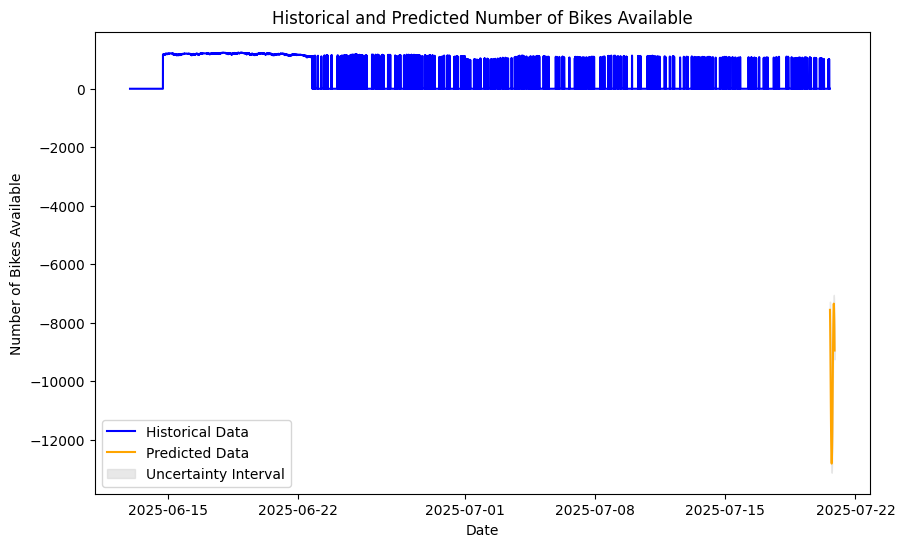

In [10]:
# Plot historical and predicted values

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df["ds"], df["y"], label="Historical Data", color="blue")
plt.plot(forecast["ds"], forecast["yhat"], label="Predicted Data", color="orange")
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    color="lightgray",
    alpha=0.5,
    label="Uncertainty Interval",
)
plt.xlabel("Date")
plt.ylabel("Number of Bikes Available")
plt.title("Historical and Predicted Number of Bikes Available")
plt.legend()
plt.show()